In [3]:
import os
import shutil
import subprocess
import sys

import pandas as pd

print(f"Using kernel: {sys.executable}")

# Keep the notebook on the active kernel instead of mixing in processing_venv.
sys.path = [p for p in sys.path if "processing_venv" not in p.replace('\\', '/')]
os.environ.pop("VIRTUAL_ENV", None)

required_packages = [
    "yt-dlp",
    "faster-whisper",
    "google-cloud-storage",
    "ffmpeg-python",
    "python-dotenv",
]

print("Ensuring notebook dependencies are installed in the active kernel...")
for package in required_packages:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=False)

print("Dependency check complete.")

if shutil.which("ffmpeg"):
    print("FFmpeg is available on PATH.")
else:
    print("FFmpeg is not available on PATH. Install it separately and restart the kernel.")

print("\n" + "=" * 60)
print("Setup complete. The notebook now uses the active kernel environment.")
print("=" * 60)

Using kernel: d:\conda_envs\ma_env\python.exe
Ensuring notebook dependencies are installed in the active kernel...
Dependency check complete.
FFmpeg is available on PATH.

Setup complete. The notebook now uses the active kernel environment.


In [4]:
# Load only Instagram data (Camihawke Cleaned)
camihawke_folder = "../Data/"
if os.path.exists(camihawke_folder):
    print("Loading Instagram data...")
    ig_posts = pd.read_parquet(os.path.join(camihawke_folder, "ig_posts_cleaned.parquet"))
    ig_comments = pd.read_parquet(os.path.join(camihawke_folder, "ig_comments_cleaned.parquet"))
    print(f"  ✓ Instagram posts: {len(ig_posts)} records")
    print(f"  ✓ Instagram comments: {len(ig_comments)} records")


Loading Instagram data...
  ✓ Instagram posts: 1540 records
  ✓ Instagram comments: 499752 records


In [5]:
ig_posts.head()

,media_id,caption,comments_count,like_count,media_product_type,media_type,permalink,timestamp,reach,saved,views,total_interactions,comments_downloaded,year,Not_reel,month,dayofweek,hour
0,17941939319341563,Pronta a fissarmi goal irraggiungibili anche q...,125,43223,REELS,VIDEO,https://www.instagram.com/reel/Cm6WPZRhfBB/,2023-01-02 11:53:19,906443.0,1212.0,1138605.0,44602.0,1,2023,False,1,Monday,11
1,17992425124653410,2023: ritagliarsi ancora piu tempo (prezioso) ...,34,43776,FEED,CAROUSEL_ALBUM,https://www.instagram.com/p/Cm9ZVRxj1jO/,2023-01-03 00:00:00,373101.0,160.0,0.0,43970.0,-1,2023,True,1,Tuesday,0
2,18018137773483891,Secondo voi chi è che per la seconda volta con...,102,74641,FEED,CAROUSEL_ALBUM,https://www.instagram.com/p/Cm_dQosr6Ng/,2023-01-04 11:26:30,522935.0,259.0,0.0,75003.0,1,2023,True,1,Wednesday,11
3,17949420668402803,Spero di essere stata chiara.,469,80664,REELS,VIDEO,https://www.instagram.com/reel/CnCVAF6hurE/,2023-01-05 14:11:43,1356965.0,1987.0,1692538.0,83205.0,1,2023,False,1,Thursday,14
4,17951287544459659,Oggi è il nostro anniversario. Cominciano a e...,529,86374,REELS,VIDEO,https://www.instagram.com/reel/CnHM081hyz9/,2023-01-07 00:00:00,1035853.0,1636.0,1280011.0,88625.0,-1,2023,False,1,Saturday,0


In [17]:
ig_posts.media_type.value_counts()

media_type
IMAGE             641
CAROUSEL_ALBUM    501
VIDEO             398
Name: count, dtype: int64

In [19]:
# Dictionary of video dataframes: one for FEED and one for REELS
ig_posts_video_sets = {}
if "media_product_type" in ig_posts.columns:
    ig_posts_video = ig_posts[ig_posts["media_type"] == "VIDEO"].copy()
    ig_posts_video_sets["FEED"] = ig_posts_video[ig_posts_video["media_product_type"] == "FEED"].copy()
    ig_posts_video_sets["REELS"] = ig_posts_video[ig_posts_video["media_product_type"] == "REELS"].copy()

    print(f"FEED videos: {len(ig_posts_video_sets['FEED'])}")
    print(f"REELS videos: {len(ig_posts_video_sets['REELS'])}")
else:
    print("Column 'media_product_type' not found in ig_posts.")

# Save FEED and REELS links separately
feed_links = ig_posts_video_sets.get("FEED", pd.DataFrame()).permalink.tolist()
reels_links = ig_posts_video_sets.get("REELS", pd.DataFrame()).permalink.tolist()

# Fallback if not present but video_links_by_product exists
if not feed_links and "video_links_by_product" in globals():
    feed_links = video_links_by_product.get("FEED", [])
if not reels_links and "video_links_by_product" in globals():
    reels_links = video_links_by_product.get("REELS", [])

# Persist to disk
with open("feed_links.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(feed_links))

with open("reels_links.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(reels_links))

print(f"Saved {len(feed_links)} FEED links to feed_links.txt")
print(f"Saved {len(reels_links)} REELS links to reels_links.txt")


FEED videos: 85
REELS videos: 313
Saved 85 FEED links to feed_links.txt
Saved 313 REELS links to reels_links.txt


In [20]:
import os

try:
    from faster_whisper import WhisperModel
except Exception as exc:
    raise RuntimeError("faster-whisper is not available in the active kernel. Run the setup cell first and restart the kernel if needed.") from exc

# Initialize the model once and reuse it for every video.
print("Loading Whisper large-v3-turbo on CPU...")
model = WhisperModel("large-v3-turbo", device="cpu", compute_type="float32")

def transcribe_audio(video_path, output_folder):
    """Transcribes video audio and saves timestamped text to a file."""
    print(f"Transcribing audio for {os.path.basename(video_path)}...")

    segments, info = model.transcribe(video_path, beam_size=5)

    print(f"Detected primary language: '{info.language}' with {info.language_probability * 100:.1f}% confidence")

    transcript_path = os.path.join(output_folder, "transcription.txt")

    with open(transcript_path, "w", encoding="utf-8") as f:
        for segment in segments:
            line = f"[{segment.start:.2f}s -> {segment.end:.2f}s] {segment.text}\n"
            f.write(line)
            print(line.strip())

    print(f"Successfully saved transcription to {transcript_path}")

d:\conda_envs\ma_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Whisper large-v3-turbo on CPU...


In [21]:
import os
import subprocess
import shutil
import json
from pathlib import Path
from datetime import datetime
try:
    import yt_dlp
except ImportError:
    %pip install yt-dlp
    import yt_dlp

try:
    from tqdm import tqdm
except ImportError:
    %pip install tqdm
    from tqdm import tqdm

import glob
import pandas as pd

# Configuration
DATASET_DIR = "multimodal_dataset"
SCENE_THRESHOLD = 0.4
PROCESSED_URLS_FILE = "processed_urls.txt"
FAILED_DOWNLOADS_FILE = "failed_downloads.csv"

def folder_matches_url(folder: Path, url: str) -> bool:
    """Check if a folder corresponds to a given URL by checking folder name or info.json."""
    # Fast check: folder name in url (common for yt-dlp ids)
    if folder.name in url:
        return True
    # Check .info.json files for matching webpage/original url
    for info_file in folder.glob("*.info.json"):
        try:
            data = json.loads(info_file.read_text(encoding="utf-8"))
            for key in ("webpage_url", "original_url", "url"):
                val = data.get(key)
                if isinstance(val, str) and val == url:
                    return True
        except Exception:
            continue
    return False

def check_download_status(dataset_dir, urls):
    """Check which URLs have been downloaded and return status report."""
    dataset_path = Path(dataset_dir)
    subdirs = [p for p in dataset_path.iterdir() if p.is_dir()] if dataset_path.exists() else []
    
    downloaded = []
    not_downloaded = []
    
    for url in urls:
        match = None
        for folder in subdirs:
            if folder_matches_url(folder, url):
                match = folder
                break
        
        if match is None:
            not_downloaded.append(url)
        else:
            downloaded.append((url, str(match)))
    
    return downloaded, not_downloaded

def extract_frames(video_path, output_folder):
    """Uses FFmpeg to extract first frame, 1-second frame, and scene changes."""
    os.makedirs(output_folder, exist_ok=True)

    print(f"  Extracting frames for {os.path.basename(video_path)}...")

    # 1. Extract the very first frame (0 seconds)
    first_frame_path = os.path.join(output_folder, "frame_00_first.jpg")
    subprocess.run(
        ["ffmpeg", "-y", "-i", video_path, "-ss", "00:00:00", "-vframes", "1", "-q:v", "2", first_frame_path],
        check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

    # 2. Extract the frame at exactly 1 second
    second_frame_path = os.path.join(output_folder, "frame_01_second.jpg")
    subprocess.run(
        ["ffmpeg", "-y", "-i", video_path, "-ss", "00:00:01", "-vframes", "1", "-q:v", "2", second_frame_path],
        check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

    # 3. Extract remaining frames based on scene changes
    output_pattern = os.path.join(output_folder, "frame_%04d_scene.jpg")
    command = [
        "ffmpeg", "-y", "-i", video_path, "-vf", f"select='gt(scene,{SCENE_THRESHOLD})'",
        "-vsync", "vfr", "-q:v", "2", output_pattern
    ]
    try:
        subprocess.run(command, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        print(f"  ✓ Successfully extracted frames")
    except subprocess.CalledProcessError as e:
        print(f"  ✗ Error extracting scene frames: {e}")

def process_instagram_url(url):
    """Downloads an Instagram video and extracts its data. Returns (success, result_or_error)."""
    print(f"\n▶ Processing: {url}")
    ydl_opts = {
        'outtmpl': f'{DATASET_DIR}/%(id)s/%(id)s.%(ext)s',
        'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]/best',
        'writeinfojson': True,
        'sleep_interval_requests': 15,
        'sleep_interval': 10,
        'max_sleep_interval': 50,
    }

    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            info_dict = ydl.extract_info(url, download=True)
            video_id = info_dict.get('id', 'unknown_id')

        video_folder = os.path.join(DATASET_DIR, video_id)

        # Check if metadata file exists (indicates successful download)
        info_json_path = os.path.join(video_folder, f"{video_id}.info.json")
        if not os.path.exists(info_json_path):
            error_msg = f"Metadata file not found for {video_id}"
            print(f"  ✗ {error_msg}")
            return False, error_msg

        # Look for the video file
        video_files = glob.glob(os.path.join(video_folder, "*.mp4"))
        if not video_files:
            error_msg = f"No video file found in {video_id}/ (but metadata exists)"
            print(f"  ⚠ {error_msg}")
            return False, error_msg

        video_path = video_files[0]
        frames_folder = os.path.join(video_folder, "frames")

        print(f"  ✓ Downloaded video to {video_id}/")
        extract_frames(video_path, frames_folder)
        transcribe_audio(video_path, video_folder)

        has_music = False
        if info_dict.get('acodec') and info_dict['acodec'] != 'none':
            has_music = True
        else:
            for f in info_dict.get('formats', []):
                if f.get('acodec') and f['acodec'] != 'none':
                    has_music = True
                    break

        music_title = info_dict.get('track') or info_dict.get('title')
        music_artist = info_dict.get('artist')

        result = {
            'url': url,
            'media_type': info_dict.get('media_type', 'unknown'),
            'has_music': has_music,
            'music_title': music_title if has_music else None,
            'music_artist': music_artist if has_music else None,
            'video_folder': video_folder
        }
        return True, result
        
    except Exception as e:
        error_msg = str(e)
        print(f"  ✗ Error processing {url}: {error_msg}")
        return False, error_msg

# --- Execution: Check folders and download missing ---
print("="*70)
print("STEP 1: Checking which videos are already downloaded...")
print("="*70)

# Resolve video URLs from available sources
all_urls = []
if "video_links" in globals():
    all_urls = list(video_links)
    print(f"\n✓ Using video_links: {len(all_urls)} total URLs")
elif "video_links_by_product" in globals():
    for urls_list in video_links_by_product.values():
        all_urls.extend(urls_list)
    print(f"\n✓ Using video_links_by_product: {len(all_urls)} total URLs")
elif "ig_posts" in globals() and {"media_type", "permalink"}.issubset(ig_posts.columns):
    all_urls = ig_posts.loc[ig_posts["media_type"] == "VIDEO", "permalink"].dropna().tolist()
    print(f"\n✓ Using ig_posts VIDEO posts: {len(all_urls)} total URLs")

# Deduplicate URLs
all_urls = list(dict.fromkeys(all_urls))
print(f"✓ After deduplication: {len(all_urls)} URLs to check")

# Check download status
print(f"\nScanning {DATASET_DIR}/ folder...")
downloaded, not_downloaded = check_download_status(DATASET_DIR, all_urls)

print("\n" + "="*70)
print("DOWNLOAD STATUS REPORT")
print("="*70)
print(f"✓ Already downloaded: {len(downloaded)} videos")
print(f"⬇ Need to download: {len(not_downloaded)} videos")
print(f"  Total: {len(all_urls)} videos")

if downloaded:
    print(f"\nFirst 5 downloaded videos:")
    for url, folder in downloaded[:5]:
        print(f"  • {Path(folder).name}")
    if len(downloaded) > 5:
        print(f"  ... and {len(downloaded) - 5} more")

if not_downloaded:
    print(f"\nFirst 5 videos to download:")
    for url in not_downloaded[:5]:
        print(f"  • {url}")
    if len(not_downloaded) > 5:
        print(f"  ... and {len(not_downloaded) - 5} more")

# Download missing videos with error tracking
if not_downloaded:
    print("\n" + "="*70)
    print(f"STEP 2: Downloading {len(not_downloaded)} missing videos...")
    print("="*70)
    
    collected_video_music_data = []
    failed_downloads = []
    
    for i, url in enumerate(not_downloaded, 1):
        print(f"\n[{i}/{len(not_downloaded)}]", end=" ")
        success, result = process_instagram_url(url)
        
        if success:
            collected_video_music_data.append(result)
            
            # Record the successfully processed URL
            with open(PROCESSED_URLS_FILE, "a") as f:
                f.write(f"{url}\n")
        else:
            # Track failed download
            failed_downloads.append({
                'url': url,
                'error_reason': result,
                'timestamp': datetime.now().isoformat(),
                'attempt_number': 1
            })
    
    # Save failed downloads to CSV
    if failed_downloads:
        failed_df = pd.DataFrame(failed_downloads)
        
        # Check if file already exists to append
        if os.path.exists(FAILED_DOWNLOADS_FILE):
            existing_df = pd.read_csv(FAILED_DOWNLOADS_FILE)
            failed_df = pd.concat([existing_df, failed_df], ignore_index=True)
        
        failed_df.to_csv(FAILED_DOWNLOADS_FILE, index=False)
        print(f"\n✗ Failed downloads saved to {FAILED_DOWNLOADS_FILE}")
    
    # Final summary
    print("\n" + "="*70)
    print("DOWNLOAD SUMMARY")
    print("="*70)
    print(f"✓ Successfully downloaded: {len(collected_video_music_data)} videos")
    print(f"✗ Failed downloads: {len(failed_downloads)} videos")
    print(f"  Total attempted: {len(not_downloaded)} videos")
    
    if failed_downloads:
        print(f"\nFailed video URLs:")
        for entry in failed_downloads[:10]:
            print(f"  • URL: {entry['url']}")
            print(f"    Error: {entry['error_reason'][:80]}{'...' if len(entry['error_reason']) > 80 else ''}")
        if len(failed_downloads) > 10:
            print(f"  ... and {len(failed_downloads) - 10} more failures")
    
    print("="*70)
else:
    print("\n✓ All videos already downloaded! No action needed.")

STEP 1: Checking which videos are already downloaded...

✓ Using ig_posts VIDEO posts: 398 total URLs
✓ After deduplication: 398 URLs to check

Scanning multimodal_dataset/ folder...


KeyboardInterrupt: 

copying into new folders based on reels/feeds

In [24]:
import json
import shutil
from pathlib import Path

source_dir = Path("multimodal_dataset")
target_dir = Path("multimodal_dataset_fixed")
feed_dir = target_dir / "feed"
reel_dir = target_dir / "reel"

# Recreate target folder
if target_dir.exists():
    shutil.rmtree(target_dir)
feed_dir.mkdir(parents=True, exist_ok=True)
reel_dir.mkdir(parents=True, exist_ok=True)

url_to_type = {}
for url in video_links_by_product.get("FEED", []):
    url_to_type[url] = "feed"
for url in video_links_by_product.get("REELS", []):
    url_to_type[url] = "reel"

def infer_folder_type(folder: Path):
    # 1) Match by folder name inside known URLs
    for url, media_type in url_to_type.items():
        if folder.name in url:
            return media_type

    # 2) Match by info.json contents
    for info_file in folder.glob("*.info.json"):
        try:
            data = json.loads(info_file.read_text(encoding="utf-8"))
        except Exception:
            continue

        for key in ("webpage_url", "original_url", "url"):
            val = data.get(key)
            if isinstance(val, str):
                for url, media_type in url_to_type.items():
                    if val == url or folder.name in val:
                        return media_type

        # Fallback: search any string value
        for val in data.values():
            if isinstance(val, str):
                for url, media_type in url_to_type.items():
                    if val == url or folder.name in val:
                        return media_type

    return None

copied = {"feed": 0, "reel": 0, "unknown": 0, "skipped_existing": 0}

if source_dir.exists():
    for folder in source_dir.iterdir():
        if not folder.is_dir():
            continue

        media_type = infer_folder_type(folder)
        if media_type == "feed":
            dest = feed_dir / folder.name
        elif media_type == "reel":
            dest = reel_dir / folder.name
        else:
            copied["unknown"] += 1
            continue

        # Skip if destination already exists to avoid duplicate work
        if dest.exists():
            copied["skipped_existing"] += 1
            continue

        try:
            shutil.copytree(folder, dest)
            copied[media_type] += 1
        except Exception as e:
            print(f"Error copying {folder} -> {dest}: {e}")

print(f"Feed folders copied: {copied['feed']}")
print(f"Reel folders copied: {copied['reel']}")
print(f"Unclassified folders skipped: {copied['unknown']}")
print(f"Already existing folders skipped: {copied['skipped_existing']}")
print(f"New dataset created at: {target_dir}")

NameError: name 'video_links_by_product' is not defined

In [14]:
# Check which video links are missing from the dataset folders and group them by media product type

dataset_dir = Path("multimodal_dataset")
folder_names = {p.name for p in dataset_dir.iterdir() if p.is_dir()} if dataset_dir.exists() else set()

def is_downloaded(url):
    return any(folder_name in url for folder_name in folder_names)

def get_media_product_type(url):
    for media_type, urls in video_links_by_product.items():
        if url in urls:
            return media_type
    return "UNKNOWN"

missing_video_links = [url for url in video_links if not is_downloaded(url)]

missing_video_links_by_product = {}
for url in missing_video_links:
    media_type = get_media_product_type(url)
    missing_video_links_by_product.setdefault(media_type, []).append(url)

missing_video_links_table = pd.DataFrame(
    [{"url": url, "media_product_type": get_media_product_type(url)} for url in missing_video_links]
)

print(f"Total video links: {len(video_links)}")
print(f"Missing video links: {len(missing_video_links)}")
for media_type, urls in missing_video_links_by_product.items():
    print(f"{media_type}: {len(urls)}")

display(missing_video_links_table)

Total video links: 398
Missing video links: 26
REELS: 26


,url,media_product_type
0,https://www.instagram.com/reel/CnHM081hyz9/,REELS
1,https://www.instagram.com/reel/CnMWOAShvnT/,REELS
2,https://www.instagram.com/reel/CoIHDOPjl6R/,REELS
3,https://www.instagram.com/reel/CsBVml9M4rA/,REELS
4,https://www.instagram.com/reel/CteKzi4glfy/,REELS
5,https://www.instagram.com/reel/Ct6SlWVOdOf/,REELS
6,https://www.instagram.com/reel/Ct83wETxeve/,REELS
7,https://www.instagram.com/reel/CwHmGSnt8x1/,REELS
8,https://www.instagram.com/reel/Cz8vpnztp3Q/,REELS
9,https://www.instagram.com/reel/C1EwIW1Nl0H/,REELS


In [25]:
import json
from pathlib import Path

DATASET_DIR = Path("multimodal_dataset")

# Build `urls` robustly even if `video_links` was not created in this session
if "video_links" in globals():
    _source_urls = video_links
elif "video_links_by_product" in globals():
    _source_urls = []
    for _u in video_links_by_product.values():
        _source_urls.extend(_u)
elif "ig_posts" in globals() and {"media_type", "permalink"}.issubset(ig_posts.columns):
    _source_urls = ig_posts.loc[ig_posts["media_type"] == "VIDEO", "permalink"].dropna().tolist()
else:
    _source_urls = []

urls = _source_urls.tolist() if hasattr(_source_urls, "tolist") else list(_source_urls)
urls = list(dict.fromkeys(urls))  # deduplicate while preserving order
subdirs = [p for p in DATASET_DIR.iterdir() if p.is_dir()] if DATASET_DIR.exists() else []

results = {
    "total_urls": len(urls),
    "not_downloaded": [],
    "downloaded_partial": [],
    "downloaded_complete": []
}

def folder_matches_url(folder: Path, url: str) -> bool:
    # Fast check: folder name in url (common for yt-dlp ids)
    if folder.name in url:
        return True
    # Otherwise inspect any .info.json files for matching webpage/original url
    for j in folder.glob("*.info.json"):
        try:
            data = json.loads(j.read_text(encoding="utf-8"))
        except Exception:
            continue
        for key in ("webpage_url", "original_url", "url"):
            val = data.get(key)
            if isinstance(val, str) and val == url:
                return True
        # fallback: search any string fields for the url substring
        if any(isinstance(v, str) and url in v for v in data.values()):
            return True
    return False

for url in urls:
    match = None
    for folder in subdirs:
        if folder_matches_url(folder, url):
            match = folder
            break
    if match is None:
        results["not_downloaded"].append(url)
        continue

    info_jsons = list(match.glob("*.info.json"))
    transcript = match / "transcription.txt"
    frames_folder = match / "frames"
    video_files = list(match.glob("*.mp4")) + list(match.glob("*.mkv")) + list(match.glob("*.webm"))

    checks = {
        "info_json": bool(info_jsons),
        "transcript": transcript.exists(),
        "frames_have_file": frames_folder.exists() and any(frames_folder.iterdir()),
        "video_file": bool(video_files)
    }

    if all(checks.values()):
        results["downloaded_complete"].append({"url": url, "folder": str(match)})
    else:
        results["downloaded_partial"].append({"url": url, "folder": str(match), "checks": checks})

# Print concise report
print(f"Total URLs checked: {results['total_urls']}")
print(f"Complete downloads (info.json + transcript + â‰¥1 frame + video): {len(results['downloaded_complete'])}")
print(f"Partial downloads (folder found but missing files): {len(results['downloaded_partial'])}")
print(f"Not downloaded (no folder/info found): {len(results['not_downloaded'])}")

# Optionally list problematic entries (show up to 10 each)
if results["downloaded_partial"]:
    print("\nExamples of partial (up to 10):")
    for e in results["downloaded_partial"][:10]:
        print(f" - {e['url']} -> {e['folder']} | checks: {e['checks']}")

if results["not_downloaded"]:
    print("\nExamples of not downloaded (up to 10):")
    for u in results["not_downloaded"][:10]:
        print(f" - {u}")

Total URLs checked: 398
Complete downloads (info.json + transcript + â‰¥1 frame + video): 367
Partial downloads (folder found but missing files): 5
Not downloaded (no folder/info found): 26

Examples of partial (up to 10):
 - https://www.instagram.com/reel/ClJUlu4j7yD/ -> multimodal_dataset\ClJUlu4j7yD | checks: {'info_json': True, 'transcript': False, 'frames_have_file': True, 'video_file': True}
 - https://www.instagram.com/p/By2ds26Do4M/ -> multimodal_dataset\By2ds26Do4M | checks: {'info_json': True, 'transcript': False, 'frames_have_file': True, 'video_file': True}
 - https://www.instagram.com/p/BZdlVVxAnwQ/ -> multimodal_dataset\BZdlVVxAnwQ | checks: {'info_json': True, 'transcript': False, 'frames_have_file': True, 'video_file': True}
 - https://www.instagram.com/p/BPZ0taWDwY6/ -> multimodal_dataset\BPZ0taWDwY6 | checks: {'info_json': True, 'transcript': False, 'frames_have_file': True, 'video_file': True}
 - https://www.instagram.com/p/BMtWg1VjRYo/ -> multimodal_dataset\BMtWg1Vj

In [26]:
# Match "not downloaded" URLs with ig_posts (+ optional ig_comments) and check if any folder still exists in dataset

not_downloaded_urls = []
if "results" in globals() and isinstance(results, dict):
    not_downloaded_urls = list(results.get("not_downloaded", []))
elif "missing_video_links" in globals():
    not_downloaded_urls = list(missing_video_links)

not_downloaded_urls = list(dict.fromkeys(not_downloaded_urls))  # dedupe, keep order
print(f"Not downloaded URLs to inspect: {len(not_downloaded_urls)}")

dataset_root = DATASET_DIR if "DATASET_DIR" in globals() else Path("multimodal_dataset")
dataset_folders = [p for p in dataset_root.iterdir() if p.is_dir()] if dataset_root.exists() else []

def _folder_matches_url(folder, url):
    if folder.name in url:
        return True
    for info_file in folder.glob("*.info.json"):
        try:
            data = json.loads(info_file.read_text(encoding="utf-8"))
        except Exception:
            continue
        for key in ("webpage_url", "original_url", "url"):
            if data.get(key) == url:
                return True
    return False

url_folder_rows = []
for u in not_downloaded_urls:
    matched_folder = next((f for f in dataset_folders if _folder_matches_url(f, u)), None)
    url_folder_rows.append(
        {
            "permalink": u,
            "found_folder_in_dataset": matched_folder is not None,
            "dataset_folder": matched_folder.name if matched_folder else None,
        }
    )

url_folder_df = pd.DataFrame(url_folder_rows)

post_cols = [
    "media_id",
    "permalink",
    "media_product_type",
    "timestamp",
    "comments_count",
    "like_count",
    "views",
    "reach",
    "total_interactions",
]
post_cols = [c for c in post_cols if c in ig_posts.columns]

not_downloaded_matches_df = (
    url_folder_df.merge(ig_posts[post_cols], on="permalink", how="left")
    .sort_values(["found_folder_in_dataset", "timestamp"], ascending=[False, False])
    .reset_index(drop=True)
)

# Optional: bring in actual downloaded comments count from ig_comments (for these media_ids)
if "ig_comments" in globals() and "media_id" in ig_comments.columns and "media_id" in not_downloaded_matches_df.columns:
    ids = not_downloaded_matches_df["media_id"].dropna().astype(str).unique().tolist()
    if ids:
        comments_actual = (
            ig_comments.assign(media_id=ig_comments["media_id"].astype(str))
            .query("media_id in @ids")
            .groupby("media_id")
            .size()
            .rename("comments_rows_in_ig_comments")
            .reset_index()
        )
        not_downloaded_matches_df["media_id"] = not_downloaded_matches_df["media_id"].astype(str)
        not_downloaded_matches_df = not_downloaded_matches_df.merge(comments_actual, on="media_id", how="left")

display(not_downloaded_matches_df)
print(f"Rows matched in ig_posts: {not_downloaded_matches_df['media_id'].notna().sum()} / {len(not_downloaded_matches_df)}")
print(f"URLs with folder found anyway: {not_downloaded_matches_df['found_folder_in_dataset'].sum()}")

Not downloaded URLs to inspect: 26


,permalink,found_folder_in_dataset,dataset_folder,media_id,media_product_type,timestamp,comments_count,like_count,views,reach,total_interactions,comments_rows_in_ig_comments
0,https://www.instagram.com/reel/DVeTxJEDnKP/,False,None,18059779787689235,REELS,2026-03-04 19:03:12,494,42064,2170750.0,904190.0,58513.0,574.0
1,https://www.instagram.com/reel/DUYKX6OCMTN/,False,None,18084596204137729,REELS,2026-02-05 00:00:00,41,2482,383276.0,241365.0,3507.0,NaN
2,https://www.instagram.com/reel/DQ9Jt33iKll/,False,None,18070397630342606,REELS,2025-11-12 00:00:00,3,354,8646.0,6880.0,432.0,NaN
3,https://www.instagram.com/reel/DQ1TpHziHQt/,False,None,18084031304490453,REELS,2025-11-09 00:00:00,25,2693,397544.0,213268.0,4316.0,NaN
4,https://www.instagram.com/reel/DQwpW8WCG-B/,False,None,17865261492498131,REELS,2025-11-07 00:00:00,60,5263,225262.0,167967.0,7876.0,NaN
5,https://www.instagram.com/reel/DKbze-PtlCe/,False,None,17916940125000883,REELS,2025-06-03 00:00:00,26,3601,338385.0,230853.0,3620.0,NaN
6,https://www.instagram.com/reel/DHqgDUytxS1/,False,None,18490778632029186,REELS,2025-03-26 00:00:00,613,14802,1045630.0,465261.0,15879.0,NaN
7,https://www.instagram.com/reel/DCTyNPFtEUK/,False,None,18162009016317652,REELS,2024-11-13 00:00:00,288,42117,1204778.0,551527.0,55304.0,NaN
8,https://www.instagram.com/reel/DBEDdbANbrY/,False,None,18018995288540284,REELS,2024-10-13 00:00:00,138,28176,924818.0,402346.0,40753.0,NaN
9,https://www.instagram.com/reel/C7wQGcqtdRV/,False,None,18032772493946279,REELS,2024-06-03 00:00:00,78,72487,2357747.0,818490.0,88970.0,NaN


Rows matched in ig_posts: 26 / 26
URLs with folder found anyway: 0


In [27]:
from pathlib import Path

# Remove the failed Instagram posts from the loaded dataset before any downstream analysis.
failed_downloads_path = Path("failed_downloads.csv")
# Define a new path for the dataset that is synced with downloaded media.
synced_posts_path = Path(camihawke_folder) / "ig_posts_media_synced.parquet"
ig_posts_original = ig_posts.copy()

if failed_downloads_path.exists():
    failed_df = pd.read_csv(failed_downloads_path)
    failed_urls = set(failed_df["url"].astype(str).str.rstrip("/"))
    
    # Create a mask to identify rows for removal
    removal_mask = ig_posts["permalink"].astype(str).str.rstrip("/").isin(failed_urls)
    removed_rows = int(removal_mask.sum())
    
    # Apply the mask to create the new, filtered DataFrame
    ig_posts_synced = ig_posts.loc[~removal_mask].copy()
    
    # Save the filtered data to the new file
    ig_posts_synced.to_parquet(synced_posts_path, index=False)
    
    print(f"Removed {removed_rows} posts based on failed_downloads.csv.")
    print(f"Saved synced dataset to: {synced_posts_path}")
    print(f"Rows before removal: {len(ig_posts_original)}")
    print(f"Rows after removal: {len(ig_posts_synced)}")
else:
    print(f"No failed_downloads.csv found at {failed_downloads_path}; nothing was removed.")

Removed 26 posts based on failed_downloads.csv.
Saved synced dataset to: ..\Data\ig_posts_media_synced.parquet
Rows before removal: 1540
Rows after removal: 1514


In [34]:
from pathlib import Path

DATASET_DIR = Path("multimodal_dataset")

video_rows = []

def get_video_duration_seconds(video_path):
    # Ensure ffprobe exists
    if shutil.which("ffprobe") is None:
        print("ffprobe not found in PATH")
        return None

    try:
        cmd = [
            "ffprobe",
            "-v", "error",
            "-show_entries", "format=duration",
            "-of", "json",
            str(video_path),
        ]
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        data = json.loads(result.stdout or "{}")
        duration = data.get("format", {}).get("duration")
        return round(float(duration), 3) if duration else None
    except Exception:
        return None

subdirs = [p for p in DATASET_DIR.iterdir() if p.is_dir()] if DATASET_DIR.exists() else []

for folder in subdirs:
    video_files = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in {".mp4", ".mkv", ".webm", ".mov"}]
    if not video_files:
        continue

    video_path = video_files[0]
    try:
        result = subprocess.run(
            ["ffprobe", "-v", "error", "-show_entries", "format=duration", "-of", "json", str(video_path)],
            capture_output=True,
            text=True,
            check=True,
        )
        data = json.loads(result.stdout or "{}")
        duration = data.get("format", {}).get("duration")
        duration_seconds = round(float(duration), 3) if duration else None
    except FileNotFoundError:
        print("ffprobe not found in PATH")
        duration_seconds = None
    except Exception:
        duration_seconds = None

    row = {
        "folder": folder.name,
        "video_file": video_path.name,
        "duration_seconds": duration_seconds,
    }

    info_files = list(folder.glob("*.info.json"))
    if info_files:
        try:
            info = json.loads(info_files[0].read_text(encoding="utf-8"))
            row["url"] = info.get("webpage_url") or info.get("original_url") or info.get("url")
        except Exception:
            row["url"] = None

    video_rows.append(row)

video_lengths_df = pd.DataFrame(video_rows).sort_values("folder").reset_index(drop=True)

if "results" in globals() and isinstance(results, dict):
    duration_by_folder = dict(zip(video_lengths_df["folder"], video_lengths_df["duration_seconds"]))
    for key in ("downloaded_complete", "downloaded_partial"):
        for item in results.get(key, []):
            if isinstance(item, dict) and "folder" in item:
                folder_name = Path(item["folder"]).name
                item["duration_seconds"] = duration_by_folder.get(folder_name)

video_lengths_df.to_csv(DATASET_DIR / "video_lengths_seconds.csv", index=False)
display(video_lengths_df.head())
print(f"Saved durations for {len(video_lengths_df)} videos to {DATASET_DIR / 'video_lengths_seconds.csv'}")

,folder,video_file,duration_seconds,url
0,B-M2NwZCOlH,B-M2NwZCOlH.mp4,16.633,https://www.instagram.com/p/B-M2NwZCOlH/
1,B-ranpdIc27,B-ranpdIc27.mp4,6.200,https://www.instagram.com/p/B-ranpdIc27/
2,B2Y__CKBE7O,B2Y__CKBE7O.mp4,55.472,https://www.instagram.com/p/B2Y__CKBE7O/
3,B4M2Wg7IPbl,B4M2Wg7IPbl.mp4,55.798,https://www.instagram.com/p/B4M2Wg7IPbl/
4,B5aPyjDI_tz,B5aPyjDI_tz.mp4,41.030,https://www.instagram.com/p/B5aPyjDI_tz/


Saved durations for 372 videos to multimodal_dataset\video_lengths_seconds.csv


Added duration_seconds to ig_posts
Videos with duration: 372
Non-videos or unmatched: 1168


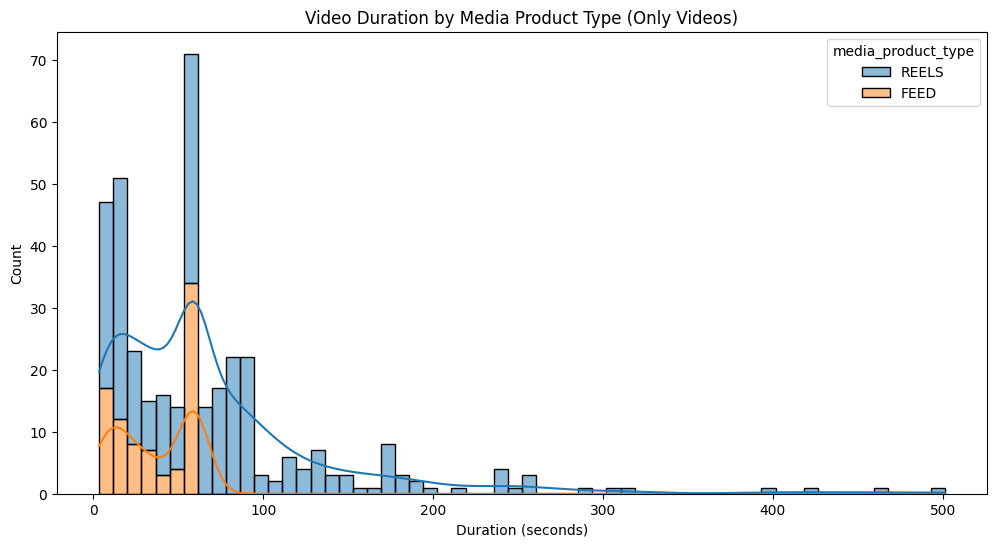


Duration statistics by media_product_type:
                    count       mean        std    min      25%     50%  \
media_product_type                                                        
FEED                 85.0  36.086635  21.900324  3.437  14.0000  35.569   
REELS               287.0  76.131167  74.332665  4.133  22.1535  59.467   

                       75%      max  
media_product_type                   
FEED                60.060   60.117  
REELS               89.507  501.178  


In [43]:
# Add duration_seconds to ig_posts by matching with video_lengths_df
if "video_lengths_df" in globals() and "ig_posts" in globals():
    # Create a mapping from url to duration_seconds
    duration_map = dict(zip(video_lengths_df["url"], video_lengths_df["duration_seconds"]))
    
    # Add duration_seconds column to ig_posts (None for non-videos)
    ig_posts["duration_seconds"] = ig_posts["permalink"].map(duration_map)
    
    print(f"Added duration_seconds to ig_posts")
    print(f"Videos with duration: {ig_posts['duration_seconds'].notna().sum()}")
    print(f"Non-videos or unmatched: {ig_posts['duration_seconds'].isna().sum()}")
    
    # Plot duration by media_product_type (only videos)
    plot_data = ig_posts[ig_posts["duration_seconds"].notna()].copy()
    
    plt.figure(figsize=(12, 6))
    sns.histplot(
        data=plot_data,
        x="duration_seconds",
        hue="media_product_type",
        bins=60,
        kde=True,
        multiple="stack"
    )
    plt.title("Video Duration by Media Product Type (Only Videos)")
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Count")
    plt.show()
    
    # Summary statistics
    print("\nDuration statistics by media_product_type:")
    print(plot_data.groupby("media_product_type")["duration_seconds"].describe())
else:
    print("video_lengths_df or ig_posts not found in globals")

In [41]:
# Find longest reel and longest feed
if "ig_posts" in globals() and "duration_seconds" in ig_posts.columns:
    videos = ig_posts[ig_posts["duration_seconds"].notna()].copy()
    
    # Longest reel
    reels = videos[videos["media_product_type"] == "REELS"]
    if not reels.empty:
        longest_reel = reels.loc[reels["duration_seconds"].idxmax()]
        print("LONGEST REEL:")
        print(f"  Duration: {longest_reel['duration_seconds']:.2f} seconds")
        print(f"  URL: {longest_reel['permalink']}")
        print(f"  Caption: {longest_reel['caption'][:100]}...")
        print(f"  Views: {longest_reel['views']:,.0f}")
        print(f"  Likes: {longest_reel['like_count']:,.0f}")
    
    # Longest feed video
    feeds = videos[videos["media_product_type"] == "FEED"]
    if not feeds.empty:
        longest_feed = feeds.loc[feeds["duration_seconds"].idxmax()]
        print("\nLONGEST FEED VIDEO:")
        print(f"  Duration: {longest_feed['duration_seconds']:.2f} seconds")
        print(f"  URL: {longest_feed['permalink']}")
        print(f"  Caption: {longest_feed['caption'][:100]}...")
        print(f"  Views: {longest_feed['views']:,.0f}")
        print(f"  Likes: {longest_feed['like_count']:,.0f}")
else:
    print("ig_posts or duration_seconds column not found")


LONGEST REEL:
  Duration: 501.18 seconds
  URL: https://www.instagram.com/reel/C52-sI7NkRR/
  Caption: E con questo video chiudiamo la serie “ricordi del tour”.  Come vi ho raccontato nelle storie lo spe...
  Views: 1,918,187
  Likes: 95,110

LONGEST FEED VIDEO:
  Duration: 60.12 seconds
  URL: https://www.instagram.com/p/BkxNRltAciT/
  Caption: Ho il sommo piacere di informarvi che è uscito sul mio feisbu il video di Parigi ma per farvi capire...
  Views: 0
  Likes: 47,893


In [46]:
import pandas as pd
import numpy as np

# Feature Engineering: Instagram Content Format Classification
# Based on historical platform feature timeline

# ============================================================================
# STEP 1: Prepare the data
# ============================================================================

# Ensure datetime column is properly parsed
ig_posts["timestamp"] = pd.to_datetime(ig_posts["timestamp"], errors="coerce")

# Create is_carousel flag (CAROUSEL_ALBUM posts are carousels)
ig_posts["is_carousel"] = (ig_posts["media_type"] == "CAROUSEL_ALBUM").astype(bool)

# Ensure duration_seconds exists; fill missing with 0 for non-videos
if "duration_seconds" not in ig_posts.columns:
    ig_posts["duration_seconds"] = 0

# ============================================================================
# STEP 2: Define classification boundaries
# ============================================================================

date_transition_1 = pd.Timestamp("2021-10-05")  # IGTV/Feed merge begins
date_transition_2 = pd.Timestamp("2022-07-21")  # Consolidation era begins

# ============================================================================
# STEP 3: Vectorized classification using np.select()
# ============================================================================

conditions = [
    # Rule A: Pre-Oct 5, 2021 (IGTV era)
    (ig_posts["timestamp"] < date_transition_1) & (ig_posts["duration_seconds"] <= 60.121),
    (ig_posts["timestamp"] < date_transition_1) & (ig_posts["duration_seconds"] > 60.121),
    
    # Rule B: Oct 5, 2021 - July 20, 2022 (Transition/Merge era)
    (ig_posts["timestamp"] >= date_transition_1) & (ig_posts["timestamp"] < date_transition_2),
    
    # Rule C: July 21, 2022+ (Post-consolidation: Reels era)
    (ig_posts["timestamp"] >= date_transition_2) & (ig_posts["is_carousel"]) & (ig_posts["duration_seconds"] <= 60),
    (ig_posts["timestamp"] >= date_transition_2) & (~ig_posts["is_carousel"]),
]

choices = [
    "Standard Feed Video",  # Pre-Oct 2021, <=60s
    "IGTV",                 # Pre-Oct 2021, >60s
    "Instagram Video Merge",# Oct 2021 - July 2022
    "Feed Carousel Video",  # July 2022+, carousel, <=60s
    "Reel",                 # July 2022+, not carousel
]

ig_posts["content_format"] = np.select(conditions, choices, default="Unclassified")

# ============================================================================
# STEP 4: Summary Statistics
# ============================================================================

print("=" * 70)
print("CONTENT FORMAT DISTRIBUTION")
print("=" * 70)

format_counts = ig_posts["content_format"].value_counts()
print(format_counts)

print("\n" + "=" * 70)
print("AVERAGE DURATION BY CONTENT FORMAT")
print("=" * 70)

duration_stats = ig_posts.groupby("content_format")["duration_seconds"].agg([
    ("count", "count"),
    ("mean", "mean"),
    ("min", "min"),
    ("max", "max"),
    ("std", "std")
]).round(2)

print(duration_stats)

print("\n" + "=" * 70)
print("MEDIA PRODUCT TYPE BREAKDOWN BY CONTENT FORMAT")
print("=" * 70)

breakdown = pd.crosstab(ig_posts["content_format"], ig_posts["media_product_type"])
print(breakdown)

print("\n" + "=" * 70)
print("VERIFICATION: Posts by Date Range")
print("=" * 70)

pre_oct = ig_posts[ig_posts["timestamp"] < date_transition_1].shape[0]
transition = ig_posts[(ig_posts["timestamp"] >= date_transition_1) & (ig_posts["timestamp"] < date_transition_2)].shape[0]
post_jul = ig_posts[ig_posts["timestamp"] >= date_transition_2].shape[0]

print(f"Pre-Oct 5, 2021:           {pre_oct:4d} posts")
print(f"Oct 5, 2021 - Jul 20, 2022: {transition:4d} posts")
print(f"On or after Jul 21, 2022:  {post_jul:4d} posts")
print(f"Unclassified (missing date):{(ig_posts['content_format'] == 'Unclassified').sum():4d} posts")


CONTENT FORMAT DISTRIBUTION
content_format
Unclassified             987
Reel                     310
Instagram Video Merge    135
Standard Feed Video      108
Name: count, dtype: int64

AVERAGE DURATION BY CONTENT FORMAT
                       count   mean   min     max    std
content_format                                          
Instagram Video Merge     33  42.79  8.54   89.43  24.93
Reel                     231  86.28  4.24  501.18  78.73
Standard Feed Video      108  33.11  3.44   60.12  21.84
Unclassified               0    NaN   NaN     NaN    NaN

MEDIA PRODUCT TYPE BREAKDOWN BY CONTENT FORMAT
media_product_type     FEED  REELS
content_format                    
Instagram Video Merge   102     33
Reel                     55    255
Standard Feed Video      84     24
Unclassified            986      1

VERIFICATION: Posts by Date Range
Pre-Oct 5, 2021:            825 posts
Oct 5, 2021 - Jul 20, 2022:  135 posts
On or after Jul 21, 2022:   580 posts
Unclassified (missing date): 

C:\Users\alire\AppData\Local\Temp\ipykernel_20572\649770805.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\alire\AppData\Local\Temp\ipykernel_20572\649770805.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


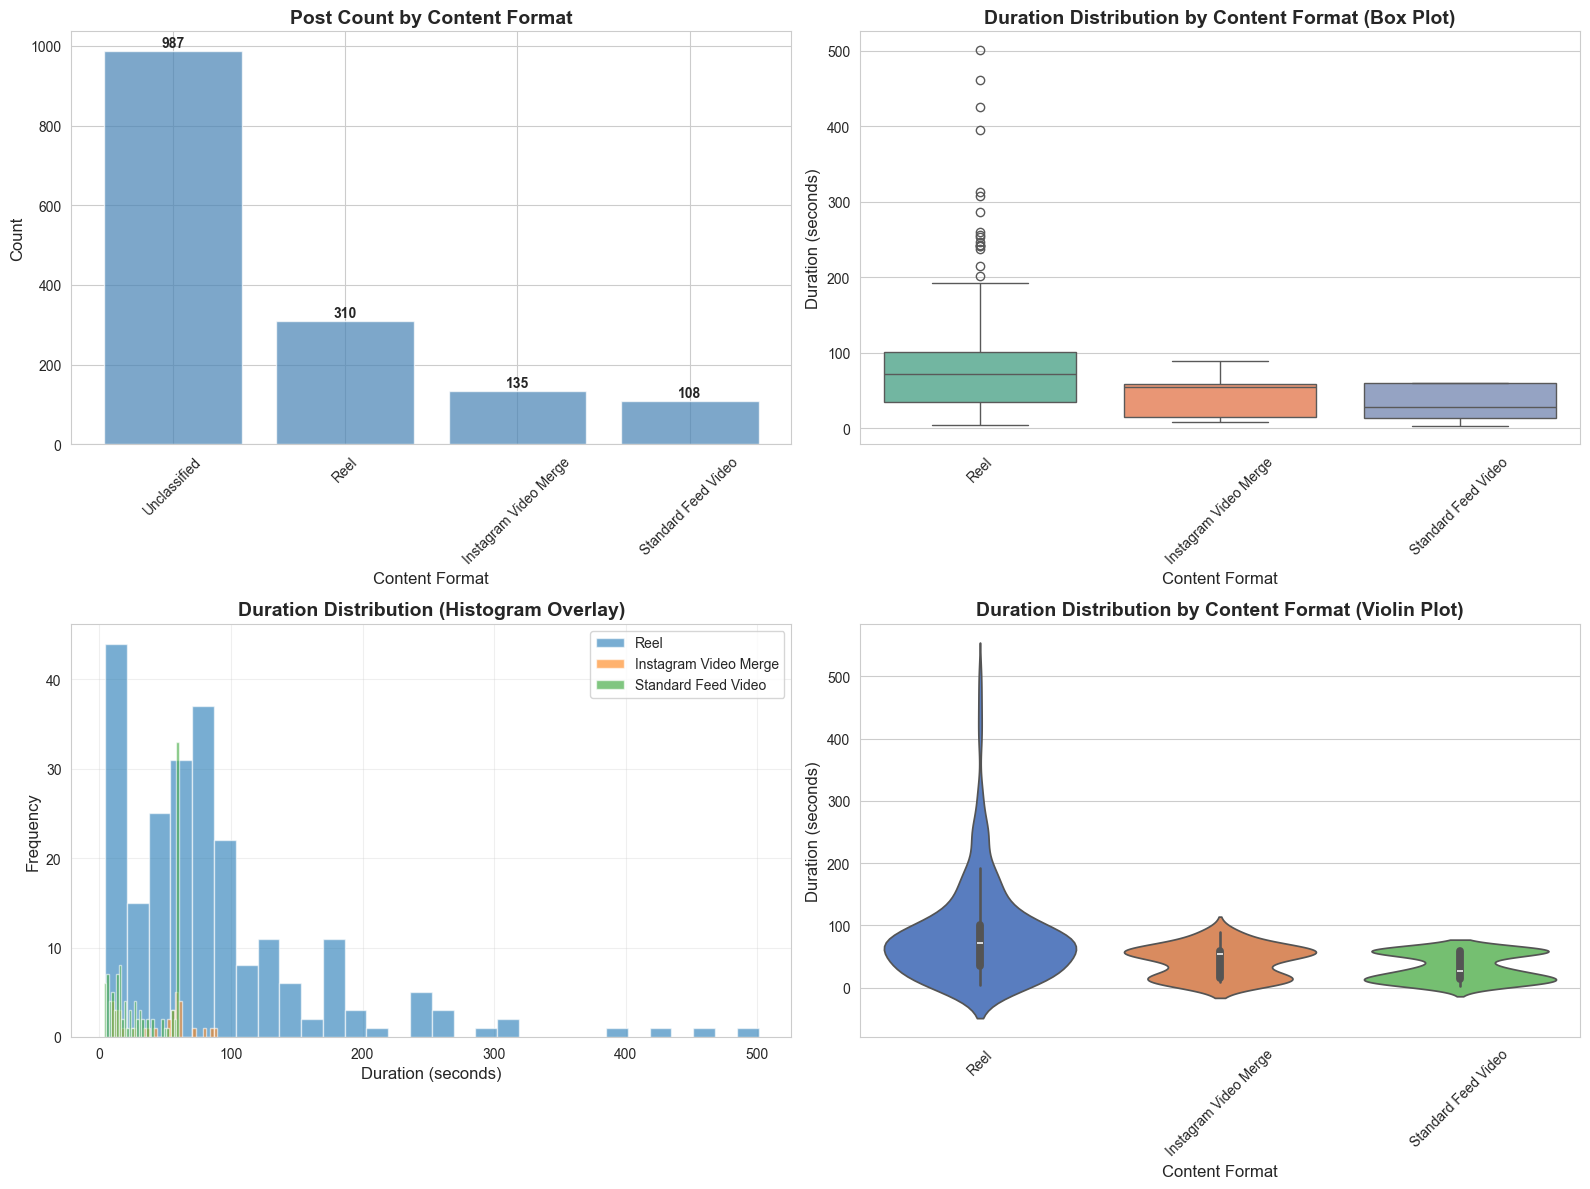


DETAILED STATISTICS BY CONTENT FORMAT

Instagram Video Merge:
  Count:  33
  Mean:   42.79s
  Median: 54.28s
  Std:    24.93s
  Min:    8.54s
  Max:    89.43s
  25th %: 15.02s
  75th %: 59.12s

Reel:
  Count:  231
  Mean:   86.28s
  Median: 72.05s
  Std:    78.73s
  Min:    4.25s
  Max:    501.18s
  25th %: 35.32s
  75th %: 100.65s

Standard Feed Video:
  Count:  108
  Mean:   33.11s
  Median: 27.55s
  Std:    21.84s
  Min:    3.44s
  Max:    60.12s
  25th %: 13.54s
  75th %: 59.52s


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (16, 12)

# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ============================================================================
# Plot 1: Count of posts by content_format
# ============================================================================
content_counts = ig_posts["content_format"].value_counts()
axes[0, 0].bar(content_counts.index, content_counts.values, color="steelblue", alpha=0.7)
axes[0, 0].set_title("Post Count by Content Format", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Content Format", fontsize=12)
axes[0, 0].set_ylabel("Count", fontsize=12)
axes[0, 0].tick_params(axis="x", rotation=45)
for i, v in enumerate(content_counts.values):
    axes[0, 0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# ============================================================================
# Plot 2: Distribution of duration_seconds by content_format (Box Plot)
# ============================================================================
videos_only = ig_posts[ig_posts["duration_seconds"] > 0].copy()
sns.boxplot(
    data=videos_only,
    x="content_format",
    y="duration_seconds",
    ax=axes[0, 1],
    palette="Set2"
)
axes[0, 1].set_title("Duration Distribution by Content Format (Box Plot)", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Content Format", fontsize=12)
axes[0, 1].set_ylabel("Duration (seconds)", fontsize=12)
axes[0, 1].tick_params(axis="x", rotation=45)

# ============================================================================
# Plot 3: Histogram of duration_seconds, stacked by content_format
# ============================================================================
for fmt in videos_only["content_format"].unique():
    data = videos_only[videos_only["content_format"] == fmt]["duration_seconds"]
    axes[1, 0].hist(data, alpha=0.6, label=fmt, bins=30)

axes[1, 0].set_title("Duration Distribution (Histogram Overlay)", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("Duration (seconds)", fontsize=12)
axes[1, 0].set_ylabel("Frequency", fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# ============================================================================
# Plot 4: Violin plot for better distribution visualization
# ============================================================================
sns.violinplot(
    data=videos_only,
    x="content_format",
    y="duration_seconds",
    ax=axes[1, 1],
    palette="muted"
)
axes[1, 1].set_title("Duration Distribution by Content Format (Violin Plot)", fontsize=14, fontweight="bold")
axes[1, 1].set_xlabel("Content Format", fontsize=12)
axes[1, 1].set_ylabel("Duration (seconds)", fontsize=12)
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# ============================================================================
# Print detailed statistics
# ============================================================================
print("\n" + "="*70)
print("DETAILED STATISTICS BY CONTENT FORMAT")
print("="*70)

for fmt in sorted(ig_posts["content_format"].unique()):
    subset = videos_only[videos_only["content_format"] == fmt]["duration_seconds"]
    if len(subset) > 0:
        print(f"\n{fmt}:")
        print(f"  Count:  {len(subset)}")
        print(f"  Mean:   {subset.mean():.2f}s")
        print(f"  Median: {subset.median():.2f}s")
        print(f"  Std:    {subset.std():.2f}s")
        print(f"  Min:    {subset.min():.2f}s")
        print(f"  Max:    {subset.max():.2f}s")
        print(f"  25th %: {subset.quantile(0.25):.2f}s")
        print(f"  75th %: {subset.quantile(0.75):.2f}s")


Total Reels: 231
Years covered: [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
Posts per year:
year
2022    45
2023    56
2024    60
2025    49
2026    21
Name: count, dtype: int64



C:\Users\alire\AppData\Local\Temp\ipykernel_20572\973863344.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\alire\AppData\Local\Temp\ipykernel_20572\973863344.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


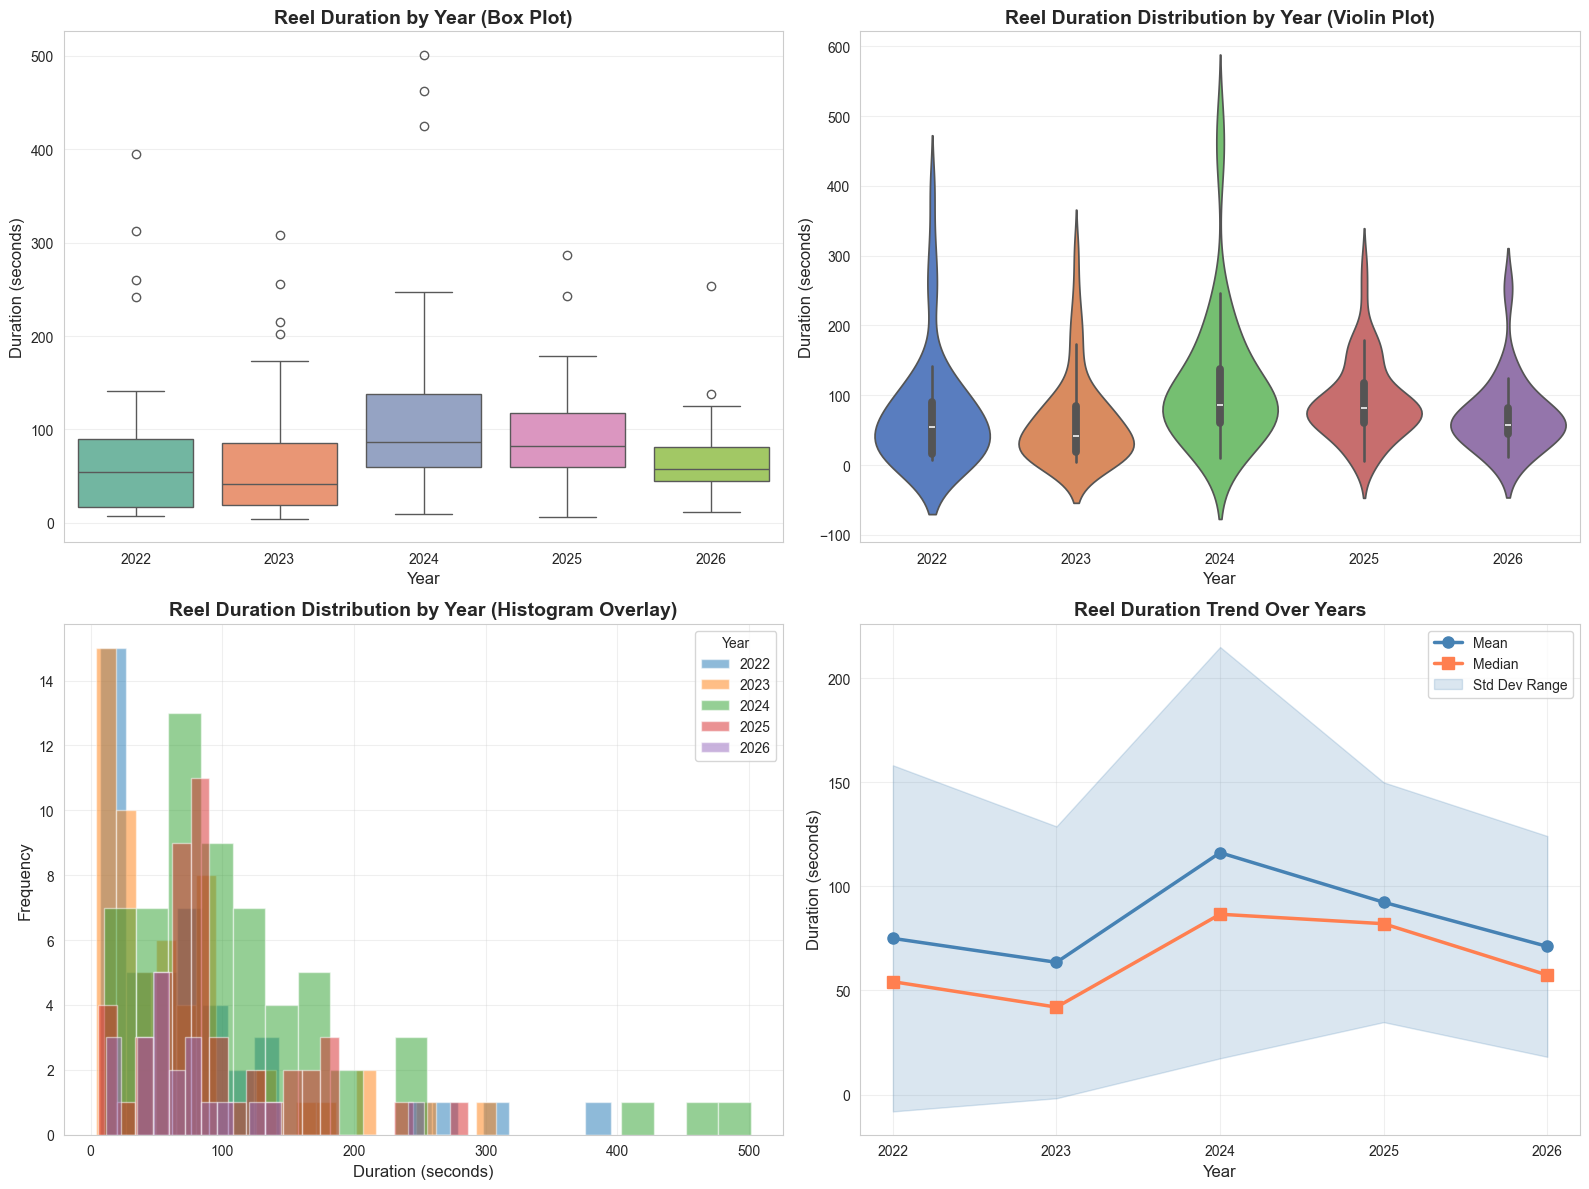


REEL DURATION STATISTICS BY YEAR

2022:
  Count:    45 reels
  Mean:     75.04s
  Median:   54.23s
  Std:      83.15s
  Min:       7.33s
  Max:     394.93s
  25th %:   16.53s
  75th %:   89.97s

2023:
  Count:    56 reels
  Mean:     63.53s
  Median:   42.00s
  Std:      65.31s
  Min:       4.25s
  Max:     307.60s
  25th %:   18.91s
  75th %:   85.27s

2024:
  Count:    60 reels
  Mean:    116.21s
  Median:   86.64s
  Std:      98.82s
  Min:       9.87s
  Max:     501.18s
  25th %:   59.77s
  75th %:  137.52s

2025:
  Count:    49 reels
  Mean:     92.40s
  Median:   82.08s
  Std:      57.60s
  Min:       5.87s
  Max:     286.51s
  25th %:   59.76s
  75th %:  117.68s

2026:
  Count:    21 reels
  Mean:     71.17s
  Median:   57.43s
  Std:      53.05s
  Min:      11.23s
  Max:     253.13s
  25th %:   44.61s
  75th %:   81.24s

YEAR-OVER-YEAR TREND
 year       mean  median       std
 2022  75.044689 54.2330 83.150991
 2023  63.532036 41.9995 65.309969
 2024 116.213217 86.6440 98.816847

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter to only Reels with valid duration
reels = ig_posts[(ig_posts["content_format"] == "Reel") & (ig_posts["duration_seconds"] > 0)].copy()

# Extract year from timestamp
reels["year"] = reels["timestamp"].dt.year

# Sort years for better visualization
reels_by_year = reels.sort_values("year")
years = sorted(reels["year"].unique())

print(f"Total Reels: {len(reels)}")
print(f"Years covered: {years}")
print(f"Posts per year:\n{reels['year'].value_counts().sort_index()}\n")

# ============================================================================
# Create figure with multiple subplots
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ============================================================================
# Plot 1: Box plot - Duration by Year
# ============================================================================
sns.boxplot(
    data=reels_by_year,
    x="year",
    y="duration_seconds",
    ax=axes[0, 0],
    palette="Set2"
)
axes[0, 0].set_title("Reel Duration by Year (Box Plot)", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Year", fontsize=12)
axes[0, 0].set_ylabel("Duration (seconds)", fontsize=12)
axes[0, 0].grid(alpha=0.3, axis="y")

# ============================================================================
# Plot 2: Violin plot - Distribution shape by Year
# ============================================================================
sns.violinplot(
    data=reels_by_year,
    x="year",
    y="duration_seconds",
    ax=axes[0, 1],
    palette="muted"
)
axes[0, 1].set_title("Reel Duration Distribution by Year (Violin Plot)", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Year", fontsize=12)
axes[0, 1].set_ylabel("Duration (seconds)", fontsize=12)
axes[0, 1].grid(alpha=0.3, axis="y")

# ============================================================================
# Plot 3: Histogram - Overlaid histograms for each year
# ============================================================================
colors = plt.cm.tab10(range(len(years)))
for i, year in enumerate(years):
    year_data = reels[reels["year"] == year]["duration_seconds"]
    axes[1, 0].hist(year_data, alpha=0.5, label=str(year), bins=20, color=colors[i])

axes[1, 0].set_title("Reel Duration Distribution by Year (Histogram Overlay)", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("Duration (seconds)", fontsize=12)
axes[1, 0].set_ylabel("Frequency", fontsize=12)
axes[1, 0].legend(title="Year", fontsize=10)
axes[1, 0].grid(alpha=0.3)

# ============================================================================
# Plot 4: Line plot - Average duration trend over years
# ============================================================================
yearly_stats = reels.groupby("year")["duration_seconds"].agg(["mean", "median", "std"]).reset_index()

axes[1, 1].plot(yearly_stats["year"], yearly_stats["mean"], marker="o", linewidth=2.5, 
                markersize=8, label="Mean", color="steelblue")
axes[1, 1].plot(yearly_stats["year"], yearly_stats["median"], marker="s", linewidth=2.5, 
                markersize=8, label="Median", color="coral")
axes[1, 1].fill_between(
    yearly_stats["year"],
    yearly_stats["mean"] - yearly_stats["std"],
    yearly_stats["mean"] + yearly_stats["std"],
    alpha=0.2,
    color="steelblue",
    label="Std Dev Range"
)

axes[1, 1].set_title("Reel Duration Trend Over Years", fontsize=14, fontweight="bold")
axes[1, 1].set_xlabel("Year", fontsize=12)
axes[1, 1].set_ylabel("Duration (seconds)", fontsize=12)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xticks(years)

plt.tight_layout()
plt.show()

# ============================================================================
# Detailed statistics table by year
# ============================================================================
print("\n" + "="*80)
print("REEL DURATION STATISTICS BY YEAR")
print("="*80)

for year in sorted(years):
    year_reels = reels[reels["year"] == year]["duration_seconds"]
    print(f"\n{year}:")
    print(f"  Count:  {len(year_reels):4d} reels")
    print(f"  Mean:   {year_reels.mean():7.2f}s")
    print(f"  Median: {year_reels.median():7.2f}s")
    print(f"  Std:    {year_reels.std():7.2f}s")
    print(f"  Min:    {year_reels.min():7.2f}s")
    print(f"  Max:    {year_reels.max():7.2f}s")
    print(f"  25th %: {year_reels.quantile(0.25):7.2f}s")
    print(f"  75th %: {year_reels.quantile(0.75):7.2f}s")

print("\n" + "="*80)
print("YEAR-OVER-YEAR TREND")
print("="*80)
print(yearly_stats.to_string(index=False))


C:\Users\alire\AppData\Local\Temp\ipykernel_20572\398762263.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\alire\AppData\Local\Temp\ipykernel_20572\398762263.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


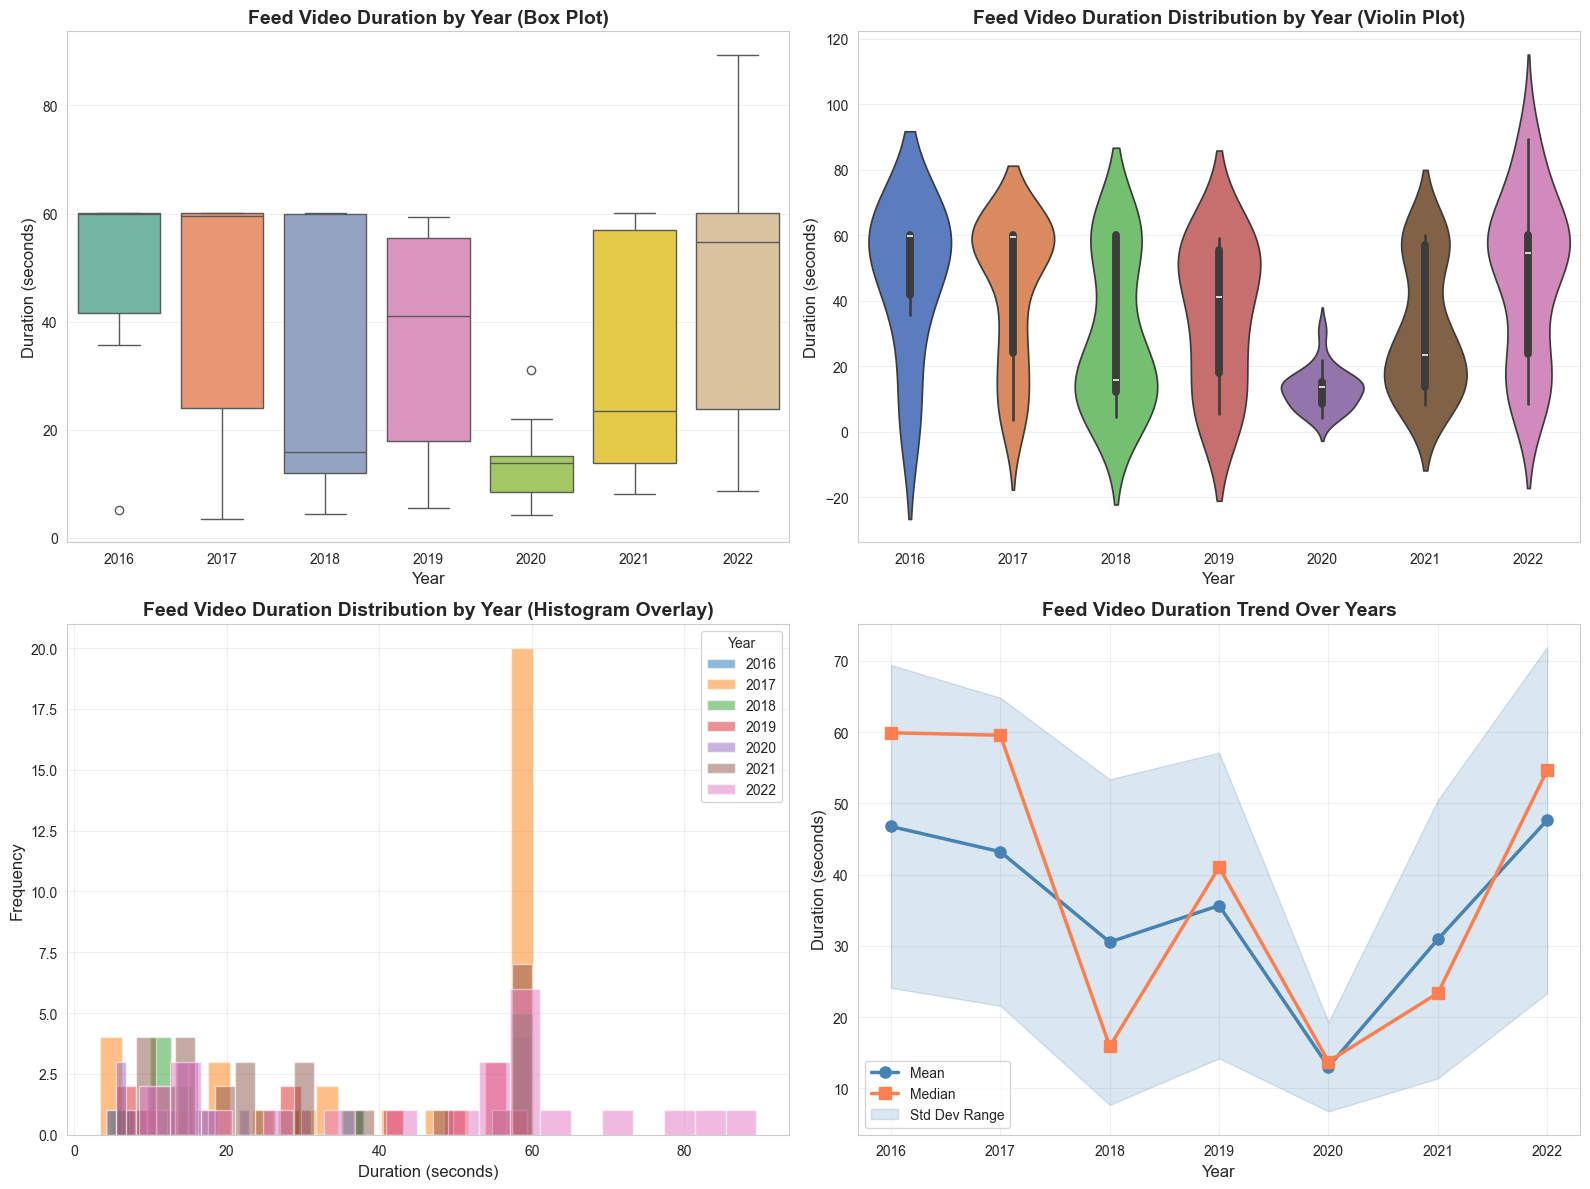

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter to only Feed videos with valid duration
feed_videos = ig_posts[(ig_posts["content_format"].isin(["Standard Feed Video", "Instagram Video Merge", "Feed Carousel Video"])) 
                       & (ig_posts["duration_seconds"] > 0)].copy()

# Extract year from timestamp
feed_videos["year"] = feed_videos["timestamp"].dt.year

# Sort years for better visualization
feed_by_year = feed_videos.sort_values("year")
years = sorted(feed_videos["year"].unique())

# ============================================================================
# Create figure with multiple subplots
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ============================================================================
# Plot 1: Box plot - Duration by Year
# ============================================================================
sns.boxplot(
    data=feed_by_year,
    x="year",
    y="duration_seconds",
    ax=axes[0, 0],
    palette="Set2"
)
axes[0, 0].set_title("Feed Video Duration by Year (Box Plot)", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Year", fontsize=12)
axes[0, 0].set_ylabel("Duration (seconds)", fontsize=12)
axes[0, 0].grid(alpha=0.3, axis="y")

# ============================================================================
# Plot 2: Violin plot - Distribution shape by Year
# ============================================================================
sns.violinplot(
    data=feed_by_year,
    x="year",
    y="duration_seconds",
    ax=axes[0, 1],
    palette="muted"
)
axes[0, 1].set_title("Feed Video Duration Distribution by Year (Violin Plot)", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Year", fontsize=12)
axes[0, 1].set_ylabel("Duration (seconds)", fontsize=12)
axes[0, 1].grid(alpha=0.3, axis="y")

# ============================================================================
# Plot 3: Histogram - Overlaid histograms for each year
# ============================================================================
colors = plt.cm.tab10(range(len(years)))
for i, year in enumerate(years):
    year_data = feed_videos[feed_videos["year"] == year]["duration_seconds"]
    axes[1, 0].hist(year_data, alpha=0.5, label=str(year), bins=20, color=colors[i])

axes[1, 0].set_title("Feed Video Duration Distribution by Year (Histogram Overlay)", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("Duration (seconds)", fontsize=12)
axes[1, 0].set_ylabel("Frequency", fontsize=12)
axes[1, 0].legend(title="Year", fontsize=10)
axes[1, 0].grid(alpha=0.3)

# ============================================================================
# Plot 4: Line plot - Average duration trend over years
# ============================================================================
yearly_stats = feed_videos.groupby("year")["duration_seconds"].agg(["mean", "median", "std"]).reset_index()

axes[1, 1].plot(yearly_stats["year"], yearly_stats["mean"], marker="o", linewidth=2.5, 
                markersize=8, label="Mean", color="steelblue")
axes[1, 1].plot(yearly_stats["year"], yearly_stats["median"], marker="s", linewidth=2.5, 
                markersize=8, label="Median", color="coral")
axes[1, 1].fill_between(
    yearly_stats["year"],
    yearly_stats["mean"] - yearly_stats["std"],
    yearly_stats["mean"] + yearly_stats["std"],
    alpha=0.2,
    color="steelblue",
    label="Std Dev Range"
)

axes[1, 1].set_title("Feed Video Duration Trend Over Years", fontsize=14, fontweight="bold")
axes[1, 1].set_xlabel("Year", fontsize=12)
axes[1, 1].set_ylabel("Duration (seconds)", fontsize=12)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xticks(years)

plt.tight_layout()
plt.show()


In [54]:
bool = feed_by_year['duration_seconds']>60
feed_by_year[bool]

,media_id,caption,comments_count,like_count,media_product_type,media_type,permalink,timestamp,reach,saved,...,total_interactions,comments_downloaded,year,Not_reel,month,dayofweek,hour,duration_seconds,is_carousel,content_format
1577,17863928323040297,L'altro giorno ho deciso di cucinare una torta...,252,6642,FEED,VIDEO,https://www.instagram.com/p/BLYRw0GDxHn/,2016-10-10 10:38:34,1828.0,440.0,...,7335.0,1,2016,False,10,Monday,10,60.060,False,Standard Feed Video
1570,17843916751161126,Già dai miei primi tre anni di vita emergono i...,71,3317,FEED,VIDEO,https://www.instagram.com/p/BMWNEr-DHdT/,2016-11-03 11:50:30,1815.0,113.0,...,3501.0,1,2016,False,11,Thursday,11,60.070,False,Standard Feed Video
1556,17868000967052097,Qualche giorno fa alla festa di radio sonica s...,19,1326,FEED,VIDEO,https://www.instagram.com/p/BOhLE6tjACy/,2016-12-27 11:07:29,1454.0,53.0,...,1398.0,1,2016,False,12,Tuesday,11,60.070,False,Standard Feed Video
1480,17860520857183158,Nonostante Daniele Bossari stia ancora indagan...,55,5016,FEED,VIDEO,https://www.instagram.com/p/BVuGHjAAs35/,2017-06-24 11:14:03,1716.0,250.0,...,5321.0,1,2017,False,6,Saturday,11,60.116,False,Standard Feed Video
1483,17844669679199939,Con oggi chiudo la triade dei concerti a sfond...,11,1726,FEED,VIDEO,https://www.instagram.com/p/BVg56HXgKT-/,2017-06-19 08:17:14,1716.0,70.0,...,1807.0,1,2017,False,6,Monday,8,60.070,False,Standard Feed Video
1484,17871475918126636,Vi racconto cosa è successo ieri sera sarò mol...,60,5298,FEED,VIDEO,https://www.instagram.com/p/BVcE2B0AtUy/,2017-06-17 11:16:35,1586.0,169.0,...,5527.0,1,2017,False,6,Saturday,11,60.070,False,Standard Feed Video
1397,17891348317190020,Allora in pratica ieri sera e pure stasera al ...,443,17534,FEED,VIDEO,https://www.instagram.com/p/BdPgs3kgTOY/,2017-12-28 10:26:45,1933.0,636.0,...,18613.0,1,2017,False,12,Thursday,10,60.117,False,Standard Feed Video
1412,17909812216038108,Bene amici dopo l’ultima parentesi Tumbleahr p...,191,14420,FEED,VIDEO,https://www.instagram.com/p/BcCkHiHA1KU/,2017-11-28 13:11:09,3201.0,989.0,...,15600.0,1,2017,False,11,Tuesday,13,60.117,False,Standard Feed Video
1403,17853784372219985,Se ripenso alla mia adolescenza posso dire di ...,159,15919,FEED,VIDEO,https://www.instagram.com/p/Bc2Flufg6-Q/,2017-12-18 13:23:58,1910.0,1155.0,...,17233.0,1,2017,False,12,Monday,13,60.116,False,Standard Feed Video
1489,17873493631079009,Nascondi i problemi sotto al tappeto cantano i...,13,1633,FEED,VIDEO,https://www.instagram.com/p/BU_ov6zAlek/,2017-06-06 10:12:21,1432.0,44.0,...,1690.0,1,2017,False,6,Tuesday,10,60.070,False,Standard Feed Video


In [ ]:
import os
import instaloader
from pathlib import Path
from tqdm.auto import tqdm
import time
import random
import subprocess
import sys

# ============================================================================
# Ensure image_links and carousel_links are defined
# ============================================================================
if "image_links" not in globals() or not image_links:
    if "ig_posts" in globals() and "media_type" in ig_posts.columns:
        image_links = ig_posts[ig_posts["media_type"] == "IMAGE"]["permalink"].tolist()
        carousel_links = ig_posts[ig_posts["media_type"] == "CAROUSEL_ALBUM"]["permalink"].tolist()
        print(f"✓ Rebuilt image_links: {len(image_links)} posts")
        print(f"✓ Rebuilt carousel_links: {len(carousel_links)} posts")
    else:
        raise ValueError("ig_posts not found or media_type column missing. Run the data loading cells first.")

# ============================================================================
# Load environment variables from .env file
# ============================================================================
try:
    from dotenv import load_dotenv
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "python-dotenv"])
    from dotenv import load_dotenv

# Load .env file explicitly (supports both .env and .env.example)
env_files = [".env", ".env.example"]
loaded = False

for env_file in env_files:
    if os.path.exists(env_file):
        load_dotenv(env_file)
        print(f"✓ Loaded environment from: {env_file}")
        loaded = True
        break

if not loaded:
    print("⚠ Warning: No .env or .env.example file found. Using system environment variables.")
else:
    load_dotenv()

# Retrieve credentials
ig_username = os.getenv("IG_USERNAME")
ig_password = os.getenv("IG_PASSWORD")

if not ig_username:
    raise ValueError("IG_USERNAME not found in environment variables (.env or .env.example)")

print(f"✓ Instagram username loaded: {ig_username}")
print(f"✓ Instagram password loaded: {'Yes' if ig_password else 'No (will use interactive login)'}")

# ============================================================================
# Human-like pause function with jitter
# ============================================================================
def human_like_pause(min_seconds=2, max_seconds=8, variation=0.3, download_count=0):
    """
    Add realistic human-like pause with jitter.
    Simulates human behavior: occasional longer pauses, variable reaction time.
    
    Args:
        min_seconds: minimum pause duration
        max_seconds: maximum pause duration
        variation: randomness factor (0-1), higher = more variation
        download_count: track downloads for occasional longer pauses
    
    Returns:
        pause_time: duration to sleep in seconds
    """
    base_pause = random.uniform(min_seconds, max_seconds)
    
    # Add occasional longer pauses (simulating thinking/distraction) - 10% chance
    if random.random() < 0.10:
        base_pause *= random.uniform(1.5, 2.5)
    
    # Add gaussian jitter (realistic variation around base time)
    jitter = random.gauss(0, base_pause * variation)
    pause_time = max(0.5, base_pause + jitter)
    
    return pause_time

# ============================================================================
# Setup dataset directories
# ============================================================================
if 'dataset_dir' not in locals():
    dataset_dir = Path("./multimodal_dataset_fixed")
    print(f"Warning: `dataset_dir` was not defined. Defaulting to {dataset_dir}") 
else:
    dataset_dir = Path(dataset_dir)
    if dataset_dir.name == "multimodal_dataset":
        dataset_dir = dataset_dir.parent / "multimodal_dataset_fixed"
        print(f"Redirecting downloads to {dataset_dir}")

image_dir = dataset_dir / "image"
carousel_dir = dataset_dir / "carousel"
image_dir.mkdir(parents=True, exist_ok=True)
carousel_dir.mkdir(parents=True, exist_ok=True)
print(f"Image directory: {image_dir}")
print(f"Carousel directory: {carousel_dir}")

# ============================================================================
# Initialize Instaloader
# ============================================================================
L = instaloader.Instaloader(
    download_pictures=True,
    download_videos=False,
    download_video_thumbnails=False,
    download_geotags=False,
    download_comments=False,
    save_metadata=True,
    compress_json=False,
    post_metadata_txt_pattern="{date_utc}_UTC",
    max_connection_attempts=3,
)

# ============================================================================
# Handle Instagram authentication
# ============================================================================
try:
    L.load_session_from_file(ig_username)
    print(f"✓ Loaded session for user: {ig_username}")
except FileNotFoundError:
    print(f"Session file for {ig_username} not found. Logging in.")
    if ig_password:
        L.login(ig_username, ig_password)
        print(f"✓ Logged in with credentials from environment")
    else:
        print("Enter password in the prompt below:")
        L.interactive_login(ig_username)
    L.save_session_to_file()

# ============================================================================
# Check already downloaded content
# ============================================================================
already_downloaded_images = {p.name for p in image_dir.iterdir() if p.is_dir()} if image_dir.exists() else set()
already_downloaded_carousels = {p.name for p in carousel_dir.iterdir() if p.is_dir()} if carousel_dir.exists() else set()

print(f"Already downloaded images: {len(already_downloaded_images)}")
print(f"Already downloaded carousels: {len(already_downloaded_carousels)}")

# ============================================================================
# Prepare download targets
# ============================================================================
download_targets = {"IMAGE": image_links, "CAROUSEL_ALBUM": carousel_links}

filtered_targets = {}
for post_type, urls in download_targets.items():
    already_downloaded = already_downloaded_images if post_type == "IMAGE" else already_downloaded_carousels
    filtered_urls = [url for url in urls if url.split("/")[-2] not in already_downloaded]
    filtered_targets[post_type] = filtered_urls

total_posts = len(image_links) + len(carousel_links)
posts_to_download = sum(len(urls) for urls in filtered_targets.values())
print(f"Found {total_posts} images and carousels total.")
print(f"Need to download: {posts_to_download} posts")

# ============================================================================
# Download images and carousels
# ============================================================================
failed_urls = set()
download_counter = 0

for post_type, urls in filtered_targets.items():
    for url in urls:
        download_counter += 1
        try:
            shortcode = url.split("/")[-2]

            if post_type == "IMAGE":
                target_dir = image_dir
            else:
                target_dir = carousel_dir

            post_dir = target_dir / shortcode

            if post_dir.exists() and any(post_dir.iterdir()):
                continue

            post_dir.mkdir(exist_ok=True)
            print(f"[{download_counter}/{total_posts}] Downloading {post_type}: {shortcode}...")

            post = instaloader.Post.from_shortcode(L.context, shortcode)
            L.download_post(post, target=post_dir)

            for item in post_dir.glob('*'):
                if item.suffix not in ['.jpg', '.jpeg', '.png', '.mp4', '.json']:
                    try:
                        item.unlink()
                    except OSError:
                        pass

            # Human-like pause with jitter (3-12 seconds with variation)
            pause_duration = human_like_pause(min_seconds=3, max_seconds=12, variation=0.35, download_count=download_counter)
            print(f"  ⏸ Pausing {pause_duration:.2f}s (human-like delay)...\n")
            time.sleep(pause_duration)
            
        except instaloader.exceptions.LoginRequiredException:
            print("⚠ Login required. Re-authenticating...")
            try:
                if ig_password:
                    L.login(ig_username, ig_password)
                else:
                    L.interactive_login(ig_username)
                L.save_session_to_file()
                print("✓ Re-authentication successful. Retrying download...")
                post = instaloader.Post.from_shortcode(L.context, shortcode)
                L.download_post(post, target=post_dir)
                
                # Pause after retry
                pause_duration = human_like_pause(min_seconds=5, max_seconds=15, variation=0.4)
                print(f"  ⏸ Pausing {pause_duration:.2f}s after retry...\n")
                time.sleep(pause_duration)
                
            except Exception as login_exc:
                print(f"✗ Re-authentication failed: {login_exc}")
                failed_urls.add(url)
        except Exception as e:
            print(f"✗ Failed to download {url}: {e}")
            failed_urls.add(url)

# ============================================================================
# Finalize
# ============================================================================
print("\n" + "="*70)
print("IMAGE AND CAROUSEL DOWNLOAD PROCESS FINISHED")
print("="*70)
print(f"Total downloaded: {download_counter - len(failed_urls)}")
print(f"Already existed: {len(already_downloaded_images) + len(already_downloaded_carousels)}")

if failed_urls:
    print(f"✗ Number of failed downloads: {len(failed_urls)}")
    with open("failed_image_carousel_downloads.txt", "w") as f:
        for url in failed_urls:
            f.write(f"{url}\n")
    print(f"Failed URLs saved to: failed_image_carousel_downloads.txt")
else:
    print("✓ All downloads completed successfully!")


d:\conda_envs\ma_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Rebuilt image_links: 641 posts
✓ Rebuilt carousel_links: 501 posts
✓ Loaded environment from: .env.example
✓ Instagram username loaded: shahrokhi_alireza
✓ Instagram password loaded: Yes
Image directory: multimodal_dataset_fixed\image
Carousel directory: multimodal_dataset_fixed\carousel
Loaded session from C:\Users\alire\AppData\Local\Instaloader\session-shahrokhi_alireza.
✓ Loaded session for user: shahrokhi_alireza
Already downloaded images: 342
Already downloaded carousels: 0
Found 1142 images and carousels total.
Need to download: 800 posts
[1/1142] Downloading IMAGE: BxzdOPpCucC...


JSON Query to api/v1/media/2050110777599911682/info/: 403 Forbidden - "fail" status, message "login_required" when accessing https://i.instagram.com/api/v1/media/2050110777599911682/info/ [retrying; skip with ^C]
JSON Query to api/v1/media/2050110777599911682/info/: 403 Forbidden - "fail" status, message "login_required" when accessing https://i.instagram.com/api/v1/media/2050110777599911682/info/ [retrying; skip with ^C]
Unable to fetch high quality image version of <Post BxzdOPpCucC>: JSON Query to api/v1/media/2050110777599911682/info/: 403 Forbidden - "fail" status, message "login_required" when accessing https://i.instagram.com/api/v1/media/2050110777599911682/info/


multimodal_dataset_fixed\image\BxzdOPpCucC\2019-05-23_11-51-11_UTC.jpg [2019-05-23_11-51-11_UTC] json 
  ⏸ Pausing 9.74s (human-like delay)...

[2/1142] Downloading IMAGE: BxxXb7bi6sf...


JSON Query to api/v1/media/2049522379738819359/info/: 403 Forbidden - "fail" status, message "login_required" when accessing https://i.instagram.com/api/v1/media/2049522379738819359/info/ [retrying; skip with ^C]
JSON Query to api/v1/media/2049522379738819359/info/: 403 Forbidden - "fail" status, message "login_required" when accessing https://i.instagram.com/api/v1/media/2049522379738819359/info/ [retrying; skip with ^C]
Unable to fetch high quality image version of <Post BxxXb7bi6sf>: JSON Query to api/v1/media/2049522379738819359/info/: 403 Forbidden - "fail" status, message "login_required" when accessing https://i.instagram.com/api/v1/media/2049522379738819359/info/


...

JSON Query to api/v1/media/3034493864970590584/info/: 403 Forbidden - "fail" status, message "login_required" when accessing https://i.instagram.com/api/v1/media/3034493864970590584/info/ [retrying; skip with ^C]



Too many queries in the last time. Need to wait 25 seconds, until 00:12.


JSON Query to api/v1/media/3034493864970590584/info/: 403 Forbidden - "fail" status, message "login_required" when accessing https://i.instagram.com/api/v1/media/3034493864970590584/info/ [retrying; skip with ^C]
Unable to fetch high quality image version of <Post CocsBe-rJl4>: JSON Query to api/v1/media/3034493864970590584/info/: 403 Forbidden - "fail" status, message "login_required" when accessing https://i.instagram.com/api/v1/media/3034493864970590584/info/


multimodal_dataset_fixed\carousel\CocsBe-rJl4\2023-02-09_16-24-39_UTC_4.jpg 

JSON Query to api/v1/media/3034493864970590584/info/: 403 Forbidden - "fail" status, message "login_required" when accessing https://i.instagram.com/api/v1/media/3034493864970590584/info/ [retrying; skip with ^C]
JSON Query to api/v1/media/3034493864970590584/info/: 403 Forbidden - "fail" status, message "login_required" when accessing https://i.instagram.com/api/v1/media/3034493864970590584/info/ [retrying; skip with ^C]


In [6]:
# Cell: Extract downloaded image and carousel links

import pandas as pd
from pathlib import Path

print("="*70)
print("EXTRACTING DOWNLOADED IMAGE AND CAROUSEL LINKS")
print("="*70)

# Define dataset directory
if 'dataset_dir' not in locals():
    dataset_dir = Path("./multimodal_dataset_fixed")
    print(f"Using dataset_dir: {dataset_dir}\n")
else:
    dataset_dir = Path(dataset_dir)
    print(f"Using existing dataset_dir: {dataset_dir}\n")

image_dir = dataset_dir / "image"
carousel_dir = dataset_dir / "carousel"

# Verify directories exist
if not image_dir.exists():
    print(f"⚠ Warning: Image directory not found: {image_dir}")
    image_shortcodes = set()
else:
    # Extract shortcodes from image directory
    image_shortcodes = {d.name for d in image_dir.iterdir() if d.is_dir()}
    print(f"✓ Found {len(image_shortcodes)} downloaded IMAGE items")

if not carousel_dir.exists():
    print(f"⚠ Warning: Carousel directory not found: {carousel_dir}")
    carousel_shortcodes = set()
else:
    # Extract shortcodes from carousel directory
    carousel_shortcodes = {d.name for d in carousel_dir.iterdir() if d.is_dir()}
    print(f"✓ Found {len(carousel_shortcodes)} downloaded CAROUSEL_ALBUM items")

total_downloaded = len(image_shortcodes) + len(carousel_shortcodes)
print(f"\n✓ Total downloaded items: {total_downloaded}")

# Match shortcodes back to ig_posts
if "ig_posts" not in globals():
    raise ValueError("ig_posts not found. Run the data loading cells first.")

print("\nMatching shortcodes to permalinks in ig_posts...")

# Extract shortcode from permalink
def extract_shortcode(permalink):
    """Extract Instagram shortcode from permalink"""
    return permalink.split('/')[-2] if '/' in permalink else permalink

# Create mapping of shortcode to permalink and media_type
ig_posts_dict = {
    extract_shortcode(row['permalink']): {
        'url': row['permalink'],
        'type': row['media_type']
    }
    for _, row in ig_posts.iterrows()
}

# Extract downloaded links
downloaded_data = []

# Add downloaded images
for shortcode in image_shortcodes:
    if shortcode in ig_posts_dict:
        downloaded_data.append({
            'shortcode': shortcode,
            'url': ig_posts_dict[shortcode]['url'],
            'type': 'IMAGE'
        })
    else:
        print(f"  ⚠ Shortcode not found in ig_posts: {shortcode}")

# Add downloaded carousels
for shortcode in carousel_shortcodes:
    if shortcode in ig_posts_dict:
        downloaded_data.append({
            'shortcode': shortcode,
            'url': ig_posts_dict[shortcode]['url'],
            'type': 'CAROUSEL_ALBUM'
        })
    else:
        print(f"  ⚠ Shortcode not found in ig_posts: {shortcode}")

# Create DataFrame
downloaded_df = pd.DataFrame(downloaded_data)

# Sort by type then shortcode
downloaded_df = downloaded_df.sort_values(['type', 'shortcode']).reset_index(drop=True)

print(f"\n✓ Successfully matched {len(downloaded_df)} items to permalinks")

# Summary statistics
image_count = len(downloaded_df[downloaded_df['type'] == 'IMAGE'])
carousel_count = len(downloaded_df[downloaded_df['type'] == 'CAROUSEL_ALBUM'])

print(f"\nDownloaded breakdown:")
print(f"  • IMAGE: {image_count}")
print(f"  • CAROUSEL_ALBUM: {carousel_count}")
print(f"  • Total: {len(downloaded_df)}")

# Save to CSV
output_file = "downloaded_links.csv"
downloaded_df.to_csv(output_file, index=False)
print(f"\n✓ Saved to local file: {output_file}")

# Also create a simpler version (URLs only) for easy reference
urls_only_df = downloaded_df[['url', 'type']].copy()
urls_output_file = "downloaded_links_urls_only.csv"
urls_only_df.to_csv(urls_output_file, index=False)
print(f"✓ Saved simplified version: {urls_output_file}")

# Display first few rows
print(f"\nFirst 5 downloaded items:")
print(downloaded_df.head())

print("\n" + "="*70)
print("EXTRACTION COMPLETE")
print("="*70)
print(f"\nFiles ready to upload to Colab:")
print(f"  1. {output_file} (with shortcodes)")
print(f"  2. {urls_output_file} (URLs only)")


EXTRACTING DOWNLOADED IMAGE AND CAROUSEL LINKS
Using existing dataset_dir: multimodal_dataset_fixed

✓ Found 342 downloaded IMAGE items
✓ Found 0 downloaded CAROUSEL_ALBUM items

✓ Total downloaded items: 342

Matching shortcodes to permalinks in ig_posts...

✓ Successfully matched 342 items to permalinks

Downloaded breakdown:
  • IMAGE: 342
  • CAROUSEL_ALBUM: 0
  • Total: 342

✓ Saved to local file: downloaded_links.csv
✓ Saved simplified version: downloaded_links_urls_only.csv

First 5 downloaded items:
     shortcode                                       url   type
0  B-7JNxCoDm2  https://www.instagram.com/p/B-7JNxCoDm2/  IMAGE
1  B-AOdSMoug4  https://www.instagram.com/p/B-AOdSMoug4/  IMAGE
2  B-J7PZci2Ga  https://www.instagram.com/p/B-J7PZci2Ga/  IMAGE
3  B-WtvO6CcDh  https://www.instagram.com/p/B-WtvO6CcDh/  IMAGE
4  B-mBuF0IXuI  https://www.instagram.com/p/B-mBuF0IXuI/  IMAGE

EXTRACTION COMPLETE

Files ready to upload to Colab:
  1. downloaded_links.csv (with shortcodes)
  2. 